# Build and evaluate an NPL model for sentimental analysis of product reviews using the amazon customer reviews dataset. Student will apply text preprocessing, classification techniques, and advanced NLP methods to analyze sentiment in reviews 

# Loading and Preprocessing the Data

In [18]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [20]:
# Load the dataset
# we use 'pandas' to load and preview the dataset. This helps us to understand the structure and contents of the review data.

df = pd.read_csv('C:\\Users\\kishr\\Desktop\\Tulsi\\Data sets from Kaggle\\Amazon_Reviews.csv', engine='python')

#preview the Dataset
df.head()

df = df[['Text', 'Rating']].dropna()
# df = df[df['Score'] != 3]  # Remove neutral for binary classification
df = df.head(10000)  # numbers for training
df.head()


,Text,Rating
0,"I registered on the website, tried to order a ...",1.0
1,Had multiple orders one turned up and driver h...,1.0
2,I informed these reprobates that I WOULD NOT B...,1.0
3,I have bought from Amazon before and no proble...,1.0
4,If I could give a lower rate I would! I cancel...,1.0


# Label Sentiment Categories Based on Ratings

In [23]:
# Label Sentiments
# 1, 2 stars → negative; 4, 5 stars → positive

df['sentiment'] = df['Rating'].apply(lambda x: 'positive' if x > 3 else 'negative')
df['sentiment'].value_counts()

sentiment
negative    8773
positive    1227
Name: count, dtype: int64

In [25]:
def clean_text(text):
    text = re.sub(r"http\S+|www\S+", '',text )      # remove links
    text = re.sub(r"[^A-Za-z0-9\s]", '', text)      # remove punctuation
    text = re.sub(r"\s+", ' ', text)                # remove extra spaces
    return text.lower().strip()

df['cleaned_text'] = df['Text'].apply(clean_text)
df[['cleaned_text', 'sentiment']].head()

,cleaned_text,sentiment
0,i registered on the website tried to order a l...,negative
1,had multiple orders one turned up and driver h...,negative
2,i informed these reprobates that i would not b...,negative
3,i have bought from amazon before and no proble...,negative
4,if i could give a lower rate i would i cancell...,negative


# Convert Text to Numerical Features Using TF-IDF

In [28]:
# Text to Numerical
# We convert cleaned text into numerical features using TF-IDF so machine learning models can interpret it.
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['sentiment']

# Split the Dataset Into Training and Testing Sets

In [31]:
# We split the data into 80% training and 20% testing to evaluate the model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Classifier (Logistic Regression)

In [34]:
#Train logistic regression classifier 
# We use Logistic Regression for classification. You can also fine-tune a transformer like BERT for better performance.
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Evaluate the Model Performance

In [37]:
#Evaluate model
# We evaluate the model using accuracy, precision, recall, and F1-score. The confusion matrix visualizes prediction correctness by sentiment.
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.92      0.99      0.96      1743
    positive       0.93      0.43      0.59       257

    accuracy                           0.92      2000
   macro avg       0.92      0.71      0.77      2000
weighted avg       0.92      0.92      0.91      2000



# Visualize result with confusion matrices and sentimental distribution plots

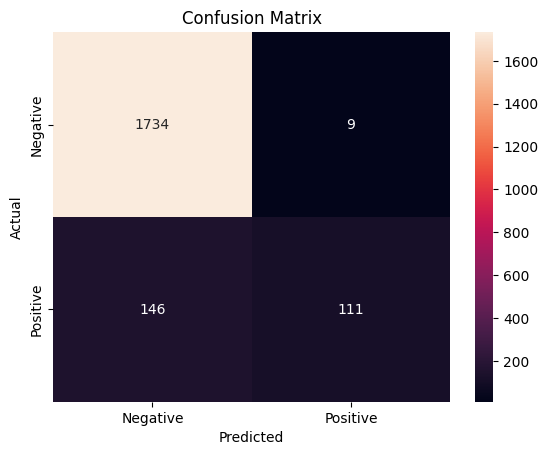

In [40]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

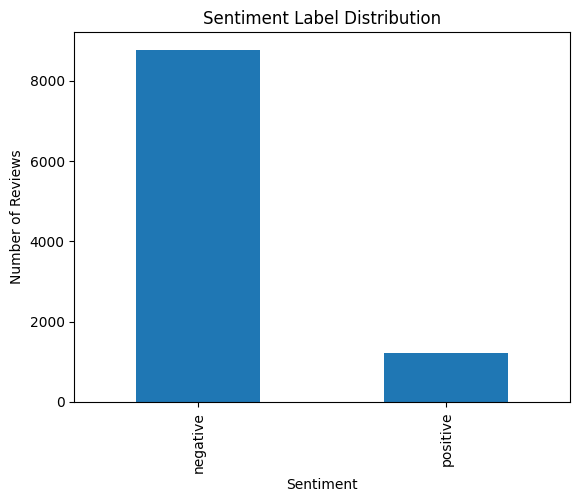

In [42]:
#Visualize sentimates distribution
df['sentiment'].value_counts().plot(kind='bar', title='Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [44]:
#For new sentiments
def predict_sentiment(Text):
    review_cleaned = clean_text(review)
    review_vector = vectorizer.transform([review_cleaned])
    return clf.predict(review_vector)[0]



In [46]:
#Predict your sentiment
def predict_sentiment():
    review = input("Enter a product review: ")
    review_cleaned = clean_text(review)
    review_vector = vectorizer.transform([review_cleaned])
    prediction = clf.predict(review_vector)[0]
    print(f"\nPredicted Sentiment: {prediction}")
    


In [48]:
predict_sentiment()

Enter a product review:  I don't like this product



Predicted Sentiment: negative
